In [16]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm

%matplotlib widget

In [33]:
# Combine CRAFTS data cubes

file1 = "CRAFTS_RA10_30_DEC24_33_+_moment2.fits"
file2 = "CRAFTS_RA30_50_DEC24_33_+_moment2.fits"
file3 = "CRAFTS_RA50_70_DEC24_33_+_moment2.fits"
file4 = "CRAFTS_RA70_90_DEC24_33_+_moment2.fits"
output_file = './combined/CRAFTS_RA10_90_DEC24_33_+_moment2.fits'
output_img = './combined/CRAFTS_RA10_90_DEC24_33_+_moment2.png'
label_index = 2
labels = ["Moment 0 (K km/s)", r"$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$", "FWHM (km/s)"]

hdul1 = fits.open(file1)
hdr1 = hdul1[0].header
data1 = hdul1[0].data

hdul2 = fits.open(file2)
hdr2 = hdul2[0].header
data2 = hdul2[0].data

hdul3 = fits.open(file3)
hdr3 = hdul3[0].header
data3 = hdul3[0].data

hdul4 = fits.open(file4)
hdr4 = hdul4[0].header
data4 = hdul4[0].data

In [34]:
print(data1.shape, data2.shape, data3.shape, data4.shape)
combined_data = np.concatenate((data4, data3, data2, data1), axis=1)
print("Shape of combined data:", combined_data.shape)
combined_header = hdr4.copy()

(364, 800) (364, 800) (364, 800) (364, 800)
Shape of combined data: (364, 3200)


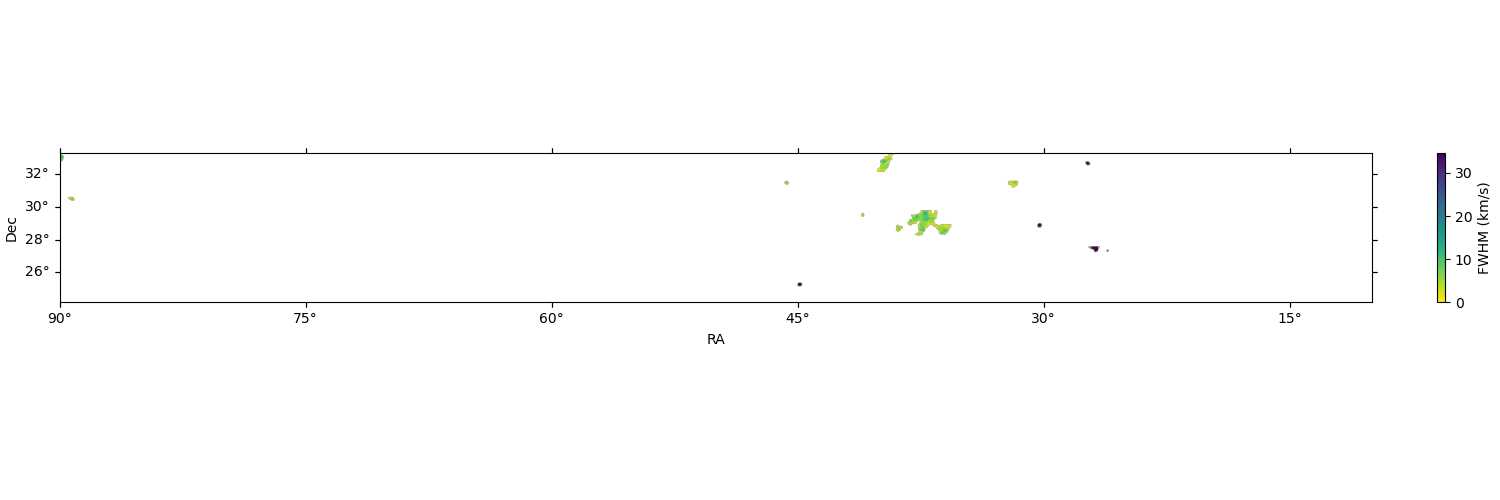

In [35]:
fig, ax = plt.subplots(
    figsize=(15, 5), layout="compressed", subplot_kw={"projection": WCS(combined_header)}
)
vmin, vmax = np.nanpercentile(combined_data, [5, 95])
norm = simple_norm(np.array(combined_data), vmin=vmin, vmax=vmax, stretch="linear")
im = ax.imshow(combined_data, norm=norm, cmap="viridis_r", origin="lower")
lon = ax.coords[0]
lat = ax.coords[1]
lon.set_major_formatter("dd")
lat.set_major_formatter("dd")
lon.set_axislabel("RA")
lat.set_axislabel("Dec")
plt.colorbar(im, ax=ax, label=labels[label_index])
plt.savefig(output_img, dpi=300, bbox_inches="tight")
plt.show()

In [36]:
hdu = fits.PrimaryHDU(data=combined_data, header=combined_header)
hdul = fits.HDUList([hdu])
hdul.writeto(output_file, overwrite=True)